💳 Fraud Detection Using Machine Learning

In this project, we work with a real-world financial transaction dataset and follow the complete Machine Learning pipeline — from data analysis to building and evaluating classification models.

🔍 Introduction: Fraud detection is essential in the financial sector to prevent monetary losses and ensure secure transactions. In this project, Machine Learning models are used to predict whether a transaction is fraudulent or legitimate based on transaction data.

🎯 Goal:
The main goal of this project is to:

1. Analyze transaction data

2. Apply different classification algorithms

3. Compare their performance

4. Identify the best model for fraud detection

🤖 Models Used:

1. Logistic Regression

2. Decision Tree

3. Random Forest

📈 Performance Metrics:

1. Accuracy

2. Precision

3. Recall

4. F1 Score

5. ROC–AUC Score

6. Confusion Matrix

✅ Result:
After evaluating all models, the best-performing algorithm was identified for fraud detection. This project shows how Machine Learning can help financial institutions detect fraud early and improve transaction security.

## Import the packages

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
#importing a csv file
df=pd.read_csv("C:/Users/vasav/OneDrive/Desktop/Fraud Detection Dataset.csv")
#View top 5 rows of a dataset
print(df.head())

  Transaction_ID  User_ID  Transaction_Amount Transaction_Type  \
0             T1     4174             1292.76   ATM Withdrawal   
1             T2     4507             1554.58   ATM Withdrawal   
2             T3     1860             2395.02   ATM Withdrawal   
3             T4     2294              100.10     Bill Payment   
4             T5     2130             1490.50      POS Payment   

   Time_of_Transaction Device_Used       Location  \
0                 16.0      Tablet  San Francisco   
1                 13.0      Mobile       New York   
2                  NaN      Mobile            NaN   
3                 15.0     Desktop        Chicago   
4                 19.0      Mobile  San Francisco   

   Previous_Fraudulent_Transactions  Account_Age  \
0                                 0          119   
1                                 4           79   
2                                 3          115   
3                                 4            3   
4                       

In [106]:
print(df.columns)

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Time_of_Transaction', 'Device_Used', 'Location',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent'],
      dtype='object')


In [108]:
#Gaining Insight into Dataset Structure 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

In [110]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
l=LabelEncoder()
df['Transaction_ID']=l.fit_transform(df['Transaction_ID'])
df['Transaction_Type']=l.fit_transform(df['Transaction_Type'])
df['Device_Used']=l.fit_transform(df['Device_Used'])
df['Location']=l.fit_transform(df['Location'])
df['Payment_Method']=l.fit_transform(df['Payment_Method'])
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,0,4174,1292.76,0,16.0,2,6,0,119,13,1,0
1,11111,4507,1554.58,0,13.0,1,5,4,79,3,0,0
2,22222,1860,2395.02,0,NaN,1,8,3,115,9,5,0
3,33333,2294,100.10,2,15.0,0,1,4,3,4,4,0
4,44444,2130,1490.50,4,19.0,1,6,2,57,7,0,0


In [112]:
#Descriptive Statistics of the Dataset
df.describe()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
count,51000.000000,51000.000000,48480.000000,51000.000000,48448.000000,51000.000000,51000.000000,51000.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,25005.562725,3005.110176,2996.249784,1.994941,11.488400,1.201412,3.719549,1.995725,60.033902,7.495588,2.152020,0.049216
std,14438.511710,1153.121107,5043.932555,1.410956,6.922954,1.063588,2.445050,1.415150,34.384131,4.020080,1.648797,0.216320
min,0.000000,1000.000000,5.030000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,12502.750000,2007.000000,1270.552500,1.000000,5.000000,0.000000,2.000000,1.000000,30.000000,4.000000,1.000000,0.000000
50%,24997.500000,2996.000000,2524.100000,2.000000,12.000000,1.000000,4.000000,2.000000,60.000000,7.000000,3.000000,0.000000
75%,37516.250000,4006.000000,3787.240000,3.000000,17.000000,2.000000,6.000000,3.000000,90.000000,11.000000,4.000000,0.000000
max,49999.000000,4999.000000,49997.800000,4.000000,23.000000,4.000000,8.000000,4.000000,119.000000,14.000000,5.000000,1.000000


In [114]:
#Summarizing Null Values in the Dataset 
df.isna().sum()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                            0
Location                               0
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                         0
Fraudulent                             0
dtype: int64

In [116]:
df = df.dropna(subset=['Transaction_Amount', 'Time_of_Transaction'])
df.reset_index(drop=True, inplace=True)

In [118]:
df.isna().sum()

Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64

In [120]:
df = df.drop(columns=['Transaction_ID', 'User_ID'])
df.head()

,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,1292.76,0,16.0,2,6,0,119,13,1,0
1,1554.58,0,13.0,1,5,4,79,3,0,0
2,100.10,2,15.0,0,1,4,3,4,4,0
3,1490.50,4,19.0,1,6,2,57,7,0,0
4,2372.04,0,15.0,0,0,3,96,14,0,0


## Computing the Correlation Matrix

In [123]:
correlation_matrix = df.corr()
print(correlation_matrix)

                                  Transaction_Amount  Transaction_Type  \
Transaction_Amount                          1.000000         -0.003599   
Transaction_Type                           -0.003599          1.000000   
Time_of_Transaction                        -0.007015          0.003167   
Device_Used                                -0.003411          0.003983   
Location                                    0.001575          0.005857   
Previous_Fraudulent_Transactions           -0.000007         -0.008644   
Account_Age                                 0.002322          0.001877   
Number_of_Transactions_Last_24H            -0.004536         -0.007944   
Payment_Method                             -0.002724         -0.005825   
Fraudulent                                  0.006452          0.004093   

                                  Time_of_Transaction  Device_Used  Location  \
Transaction_Amount                          -0.007015    -0.003411  0.001575   
Transaction_Type         

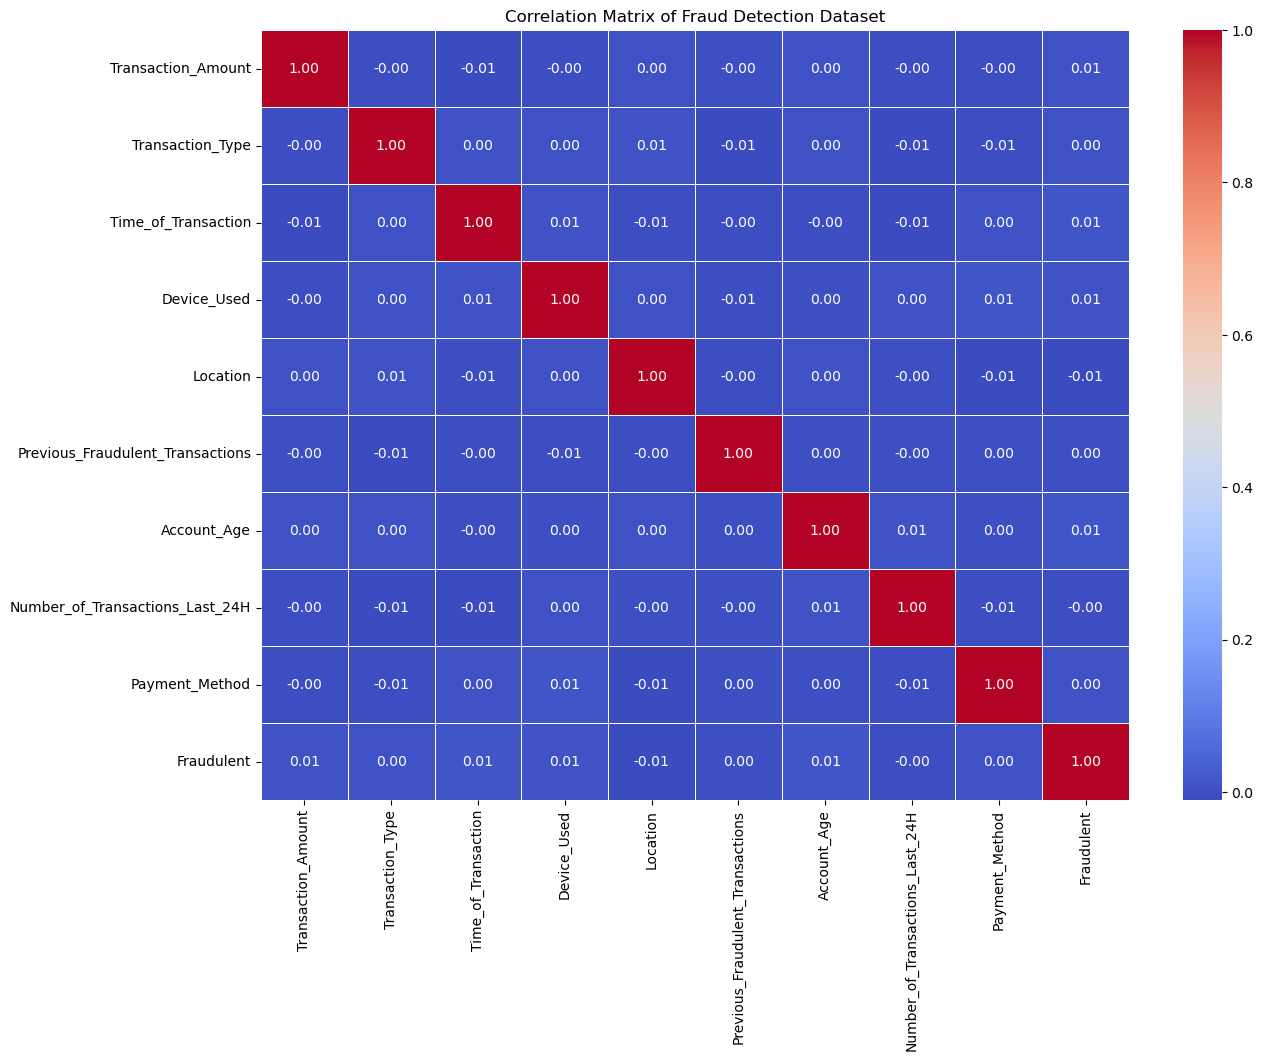

In [125]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Matrix of Fraud Detection Dataset")
plt.show()

🔍 Inference from the Correlation Heatmap (Simple Explanation)

1. Most features show very low correlation with each other and with the target (Fraudulent), indicating no strong linear relationships.

2. This suggests the dataset has low multicollinearity, which is good for ML models.

3. The target variable (Fraudulent) is not strongly dependent on any single feature, so fraud detection relies on combined patterns rather than one factor.Hence, machine learning models are more suitable than rule-based methods for this dataset.

## splitting the data in to independent and dependent variables in terms of x and y

In [129]:
X = df.drop('Fraudulent', axis=1)  
y = df['Fraudulent']               

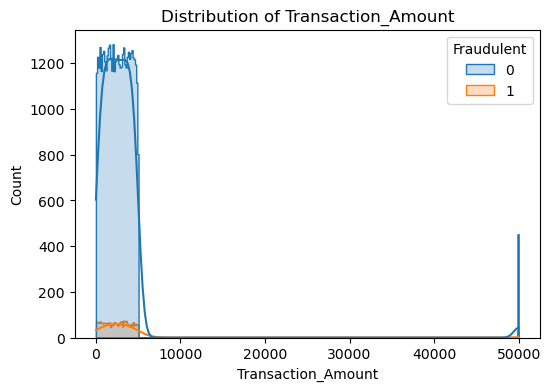

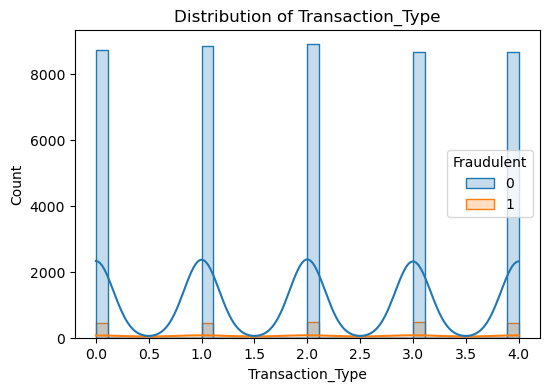

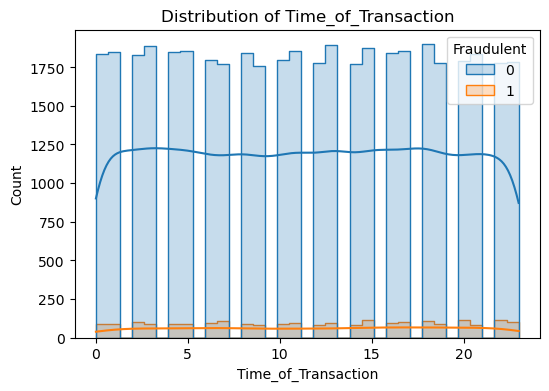

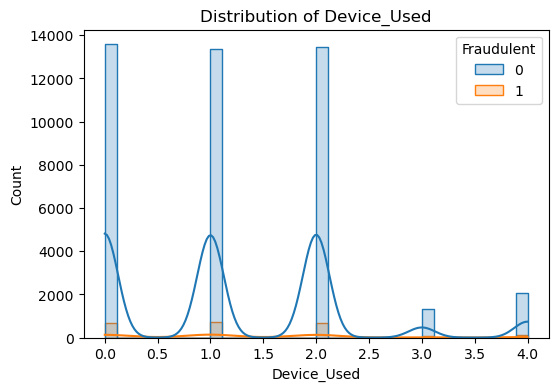

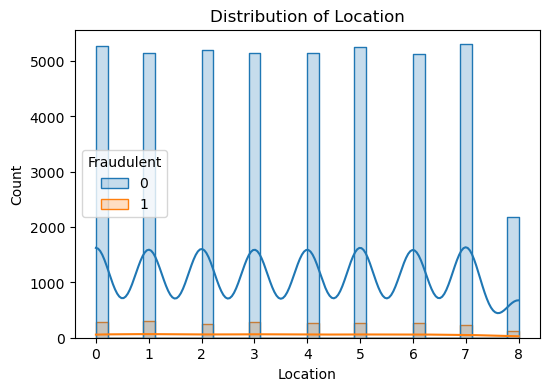

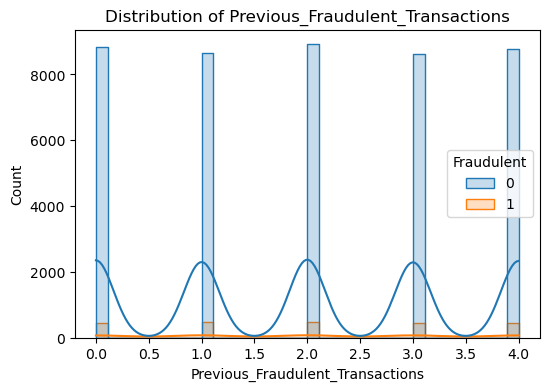

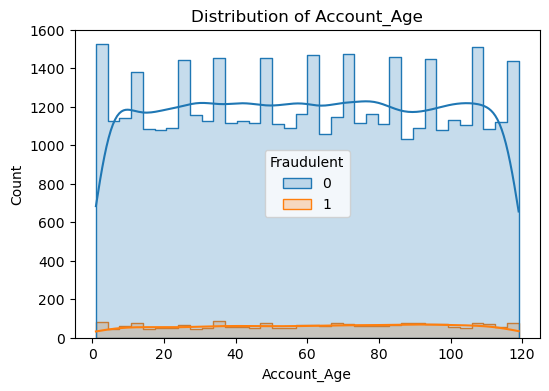

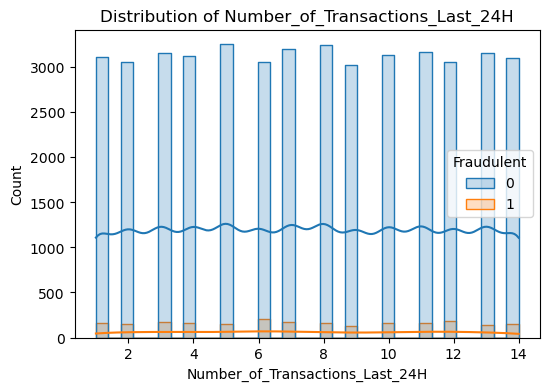

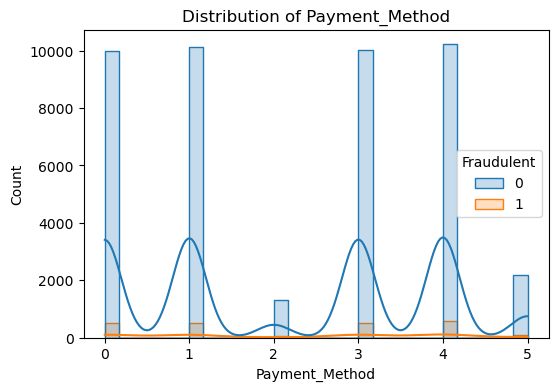

In [131]:
# Loop through all columns except the last one (Fraudulent)
for column in df.columns[:-1]:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=df,
        x=column,
        hue='Fraudulent',
        kde=True,
        element='step'
    )
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.show()


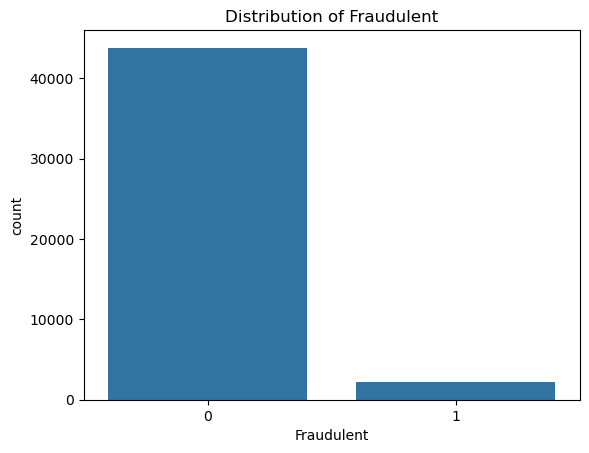

In [133]:
sns.countplot(x='Fraudulent',data=df)
plt.title("Distribution of Fraudulent")
plt.show()

The histogram shows the distribution of a binary variable labeled “Fraudulent” with values 0 (non‑fraudulent) and 1 (fraudulent).

1. The count of non‑fraudulent cases (0) is around 40,000.
2. The count of fraudulent cases (1) is roughly 2,000.
3. The data is highly imbalanced, with the majority being non‑fraudulent.

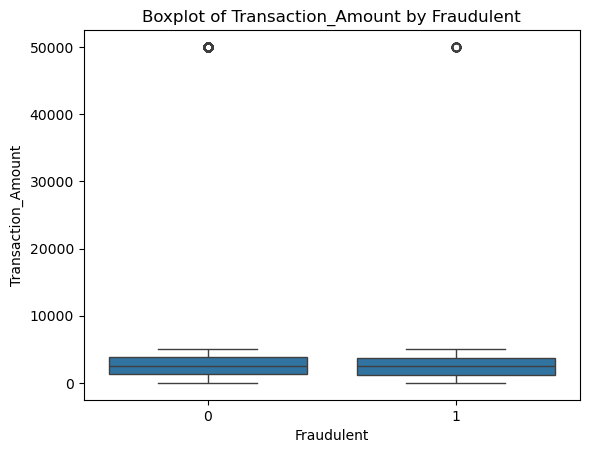

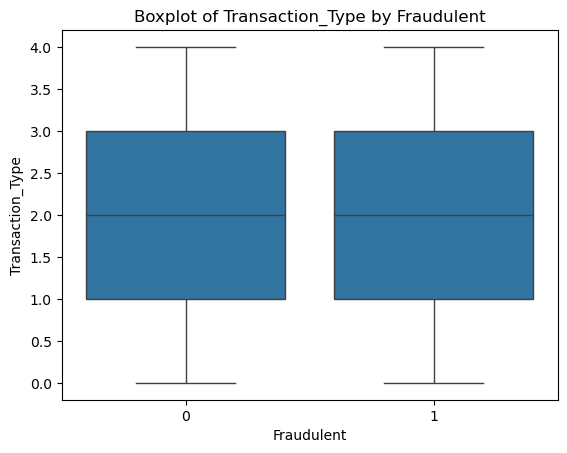

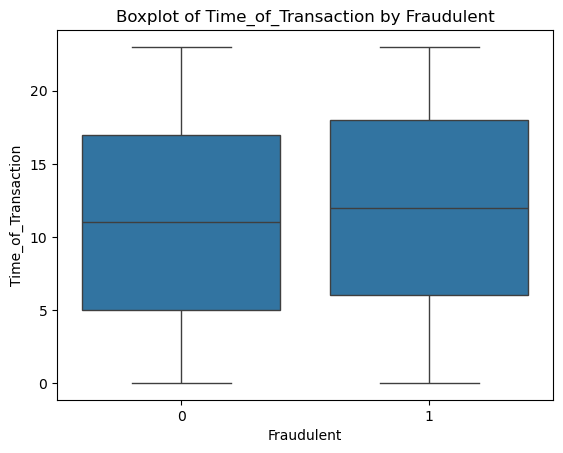

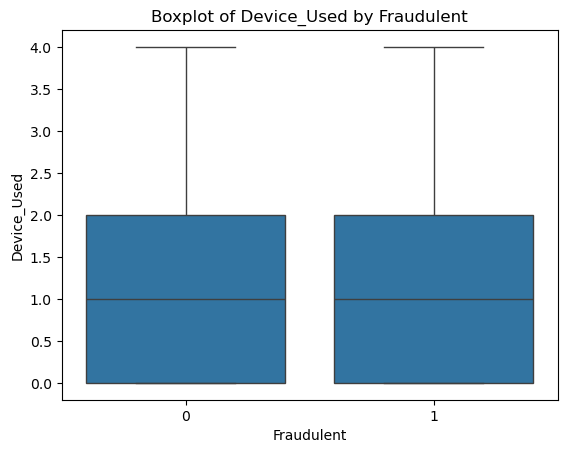

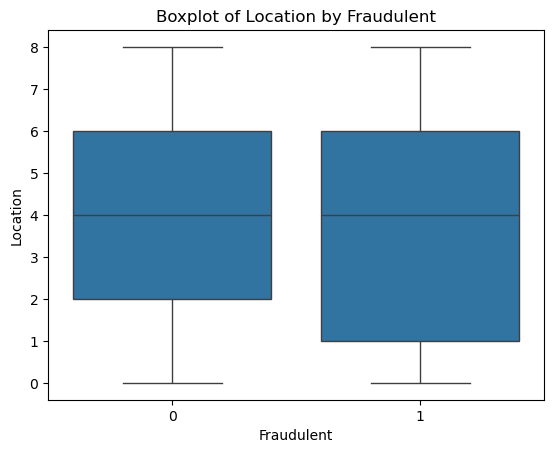

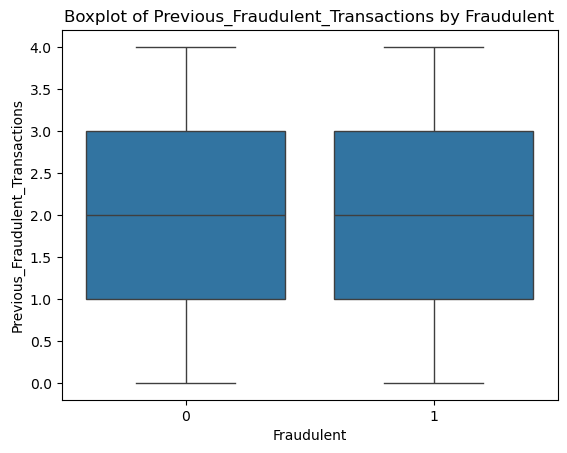

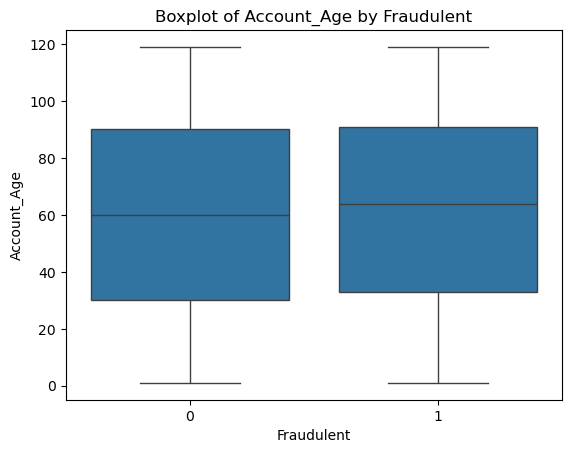

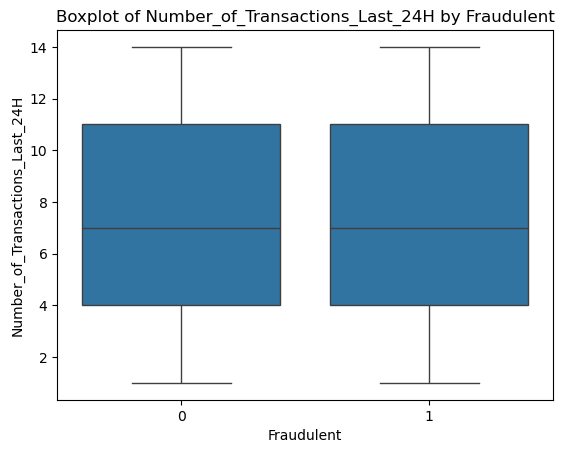

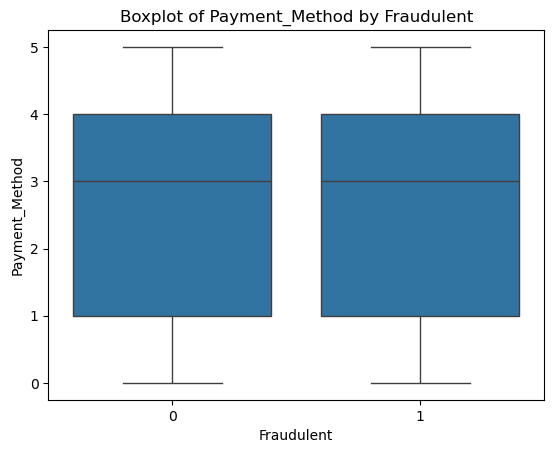

In [136]:
for column in df.columns[:-1]:
    sns.boxplot(x='Fraudulent',y=column,data=df)
    plt.title(f'Boxplot of {column} by Fraudulent')
    plt.show()

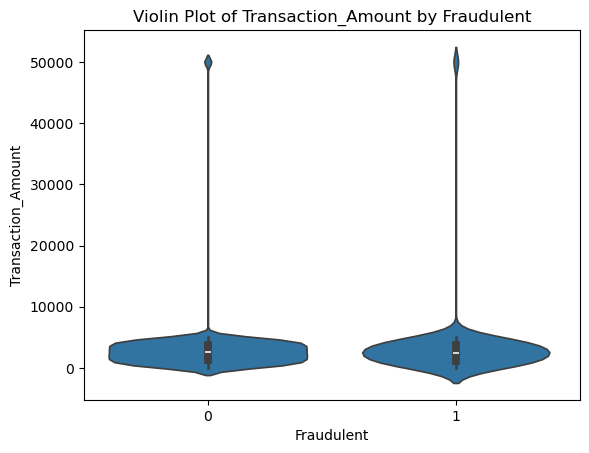

In [138]:
sns.violinplot(x='Fraudulent', y='Transaction_Amount', data=df)
plt.title("Violin Plot of Transaction_Amount by Fraudulent")
plt.xlabel("Fraudulent")
plt.ylabel("Transaction_Amount")
plt.show()

1. The plot is a violin plot showing the distribution of `Transaction_Amount` split by a binary `Fraudulent` variable (0 = non‑fraudulent, 1 = fraudulent).
2. Both distributions have similar shapes with medians near zero, but fraudulent transactions (1) show a slightly wider spread and higher extreme values compared to non‑fraudulent (0).
3. The plot suggests that fraudulent transactions can involve larger amounts, indicated by the longer whisker on the right violin.

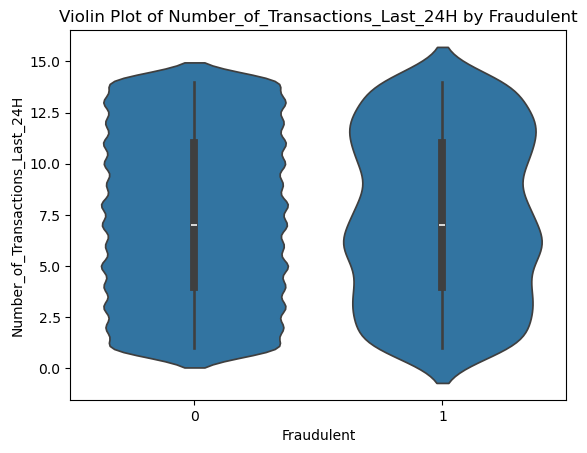

In [141]:
sns.violinplot(x='Fraudulent', y='Number_of_Transactions_Last_24H', data=df)
plt.title("Violin Plot of Number_of_Transactions_Last_24H by Fraudulent")
plt.xlabel("Fraudulent")
plt.ylabel("Number_of_Transactions_Last_24H")
plt.show()

The violin plot shows Number_of_Transactions_Last_24H vs Fraudulent (0 = non‑fraud, 1 = fraud):

1. The distributions are roughly symmetric and similar in shape.
2. Fraudulent cases have a slightly higher median number of transactions in the last 24 hours.
3. The spread of transaction counts is wider for fraudulent transactions, indicating more variability.

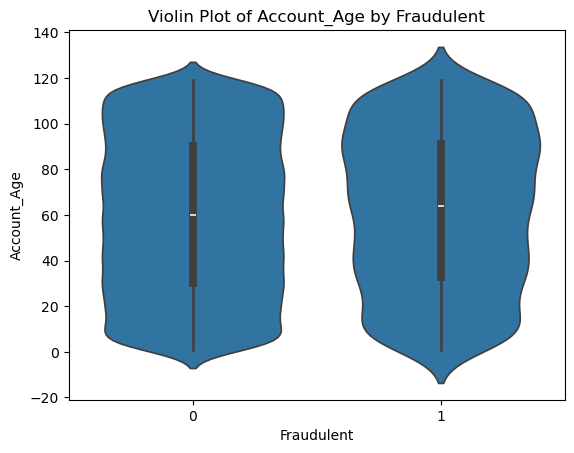

In [144]:
sns.violinplot(x='Fraudulent', y='Account_Age', data=df)
plt.title("Violin Plot of Account_Age by Fraudulent")
plt.xlabel("Fraudulent")
plt.ylabel("Account_Age")
plt.show()

1. The violin plot shows the distribution of Account_Age for two groups: non‑fraudulent (Fraudulent = 0) and fraudulent (Fraudulent = 1).
2. The shapes of the two violins are nearly identical, indicating the age distributions are similar for both fraud and non‑fraud accounts.
3. The median account age (white dot) is slightly higher for fraudulent accounts, suggesting older accounts may have a marginally greater chance of fraud.



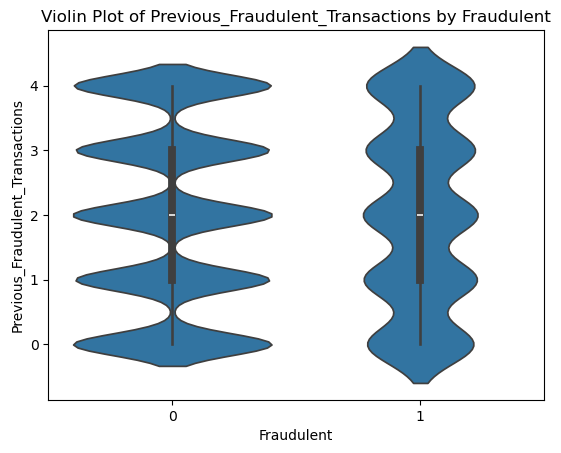

In [147]:
sns.violinplot(x='Fraudulent', y='Previous_Fraudulent_Transactions', data=df)
plt.title("Violin Plot of Previous_Fraudulent_Transactions by Fraudulent")
plt.xlabel("Fraudulent")
plt.ylabel("Previous_Fraudulent_Transactions")
plt.show()

The violin plot shows the distribution of Previous_Fraudulent_Transactions for two groups: non-fraudulent (0) and fraudulent (1).

1. The left violin (Fraudulent = 0) indicates that non-fraudulent cases have a wider spread of previous fraudulent transactions, centered around 1–2.
2. The right violin (Fraudulent = 1) shows fraudulent cases have a higher median of previous fraudulent transactions and a more concentrated distribution.
3. The plot suggests that higher numbers of previous fraudulent transactions are associated with a greater likelihood of a transaction being fraudulent.

In [150]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [152]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression

In [181]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]  

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, lr_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred, zero_division=0))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, lr_pred))

print("ROC-AUC Score:", round(roc_auc_score(y_test, lr_proba), 4))


Logistic Regression Accuracy: 0.9483

Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      8737
           1       0.00      0.00      0.00       476

    accuracy                           0.95      9213
   macro avg       0.47      0.50      0.49      9213
weighted avg       0.90      0.95      0.92      9213

Confusion Matrix:

[[8737    0]
 [ 476    0]]
ROC-AUC Score: 0.5012


## Random Forest

In [184]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]  

print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, rf_pred))

print("ROC-AUC Score:", round(roc_auc_score(y_test, rf_proba), 4))


Random Forest Accuracy: 0.9501

Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      8737
           1       1.00      0.03      0.07       476

    accuracy                           0.95      9213
   macro avg       0.97      0.52      0.52      9213
weighted avg       0.95      0.95      0.93      9213

Confusion Matrix:

[[8737    0]
 [ 460   16]]
ROC-AUC Score: 0.5199


In [186]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]  

print("Decision Tree Accuracy:", round(accuracy_score(y_test, dt_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, dt_pred, zero_division=0))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, dt_pred))

print("ROC-AUC Score:", round(roc_auc_score(y_test, dt_proba), 4))


Decision Tree Accuracy: 0.9076

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      8737
           1       0.09      0.08      0.09       476

    accuracy                           0.91      9213
   macro avg       0.52      0.52      0.52      9213
weighted avg       0.91      0.91      0.91      9213

Confusion Matrix:

[[8322  415]
 [ 436   40]]
ROC-AUC Score: 0.5183


C:\Users\vasav\AppData\Local\Temp\ipykernel_464\1905908590.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Model', y='Accuracy', data=df, palette='viridis', legend=False)


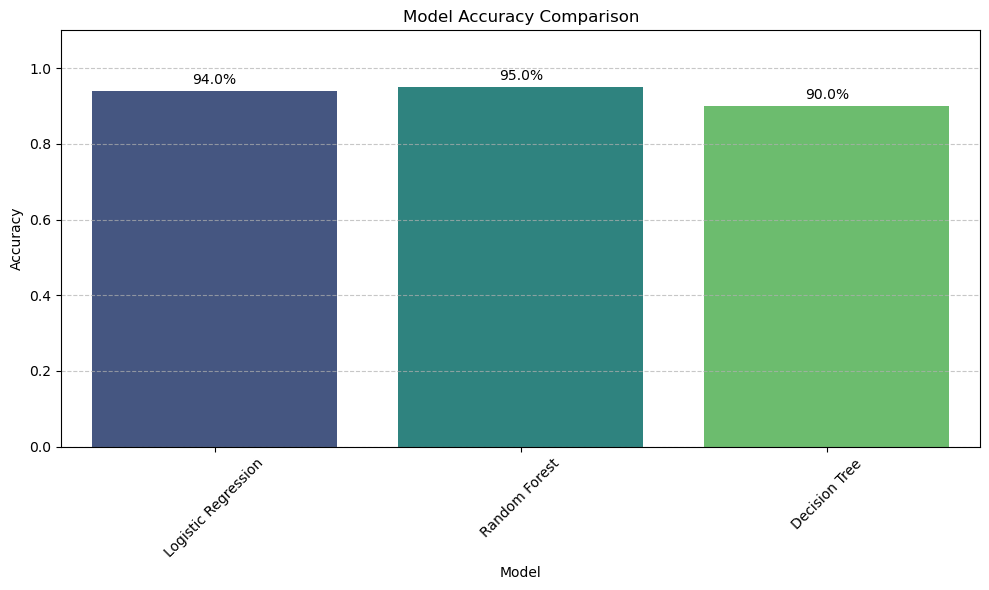

In [188]:
d = {
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree'],
    'Accuracy': [0.94, 0.95, 0.90]
}

df = pd.DataFrame(d)

# Plot
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Model', y='Accuracy', data=df, palette='viridis', legend=False)

# Add percentage labels on top of each bar
for i, bar in enumerate(barplot.patches):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,  # slightly above the bar
        f'{height * 100:.1f}%',  # format as percentage
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)  # increased limit to accommodate text
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

1. The bar chart compares the accuracy of three machine‑learning models.
2. Logistic Regression achieves 94.0% accuracy, Random Forest reaches 95.0%, and Decision Tree gets 90.0%.
3. Random Forest gives the highest accuracy, making it the best‑performing model among the three.